# TerraMind Inference and Visualization
Load trained model, make predictions on Sen1Floods11 samples, and visualize results with RGB composites and ground truth overlay.

## 1. Import Required Libraries

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import logging
import argparse
import json
from pathlib import Path
from typing import Dict, Any, Tuple
import warnings
warnings.filterwarnings('ignore')

from terratorch.tasks import SemanticSegmentationTask
from terratorch import BACKBONE_REGISTRY
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import WandbLogger

import cv2
import albumentations as A


from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS, S2_PAN_BANDS


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [15]:
root_dir=Path("/shared/home/elucas/datasets/sen1floods11_simulated")

# Load band statistics from JSON file

stats_file = f"{root_dir}/v1.1/spectral_statistics.json"
with open(stats_file, 'r') as f:
    stats = json.load(f)
    
means = []
stds = []
S2_BANDS_MAPPING = {"B02": 1, "B03": 2, "B04": 3, "B08": 4, "B05": 5, "B06": 6, "B07": 7}
for band_name in S2_BANDS:
    json_band_key = f"band_{S2_BANDS_MAPPING[band_name]}"
    means.append(stats[json_band_key]["mean"] / 10000.0)
    stds.append(stats[json_band_key]["std"] / 10000.0)

print(f"Means: {means}")
print(f"Stds: {stds}")

TARGET_SIZE = (1078, 1078)

def preprocess_mask(mask, **kwargs):
    clean_mask = np.full(mask.shape, -1, dtype=np.int64)
    clean_mask[mask == 0] = 0
    clean_mask[mask == 1] = 1
    return clean_mask

def rescale_to_reflectance(image, **kwargs):
    return (image / 10000.0).astype(np.float32)

transform = [
    A.Normalize(mean=means, std=stds),  # Rescale to [0, 1] and normalize
    # A.Lambda(image=rescale_to_reflectance),
    A.Resize(width=TARGET_SIZE[0], height=TARGET_SIZE[1], interpolation=cv2.INTER_NEAREST),
    A.Lambda(mask=preprocess_mask),
    A.pytorch.ToTensorV2(),
]


datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    data_root=root_dir,
    
    # We use the same roots for train/val/test and select samples via the given split files
    train_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    train_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),
    val_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    val_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),
    test_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    test_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),

    # Split files
    train_split=root_dir / "v1.1/splits/flood_handlabeled/flood_train_data.txt",
    val_split=root_dir / "v1.1/splits/flood_handlabeled/flood_valid_data.txt",
    test_split=root_dir / "v1.1/splits/flood_handlabeled/flood_test_data.txt",
    
    img_grep="*_S2Hand.tif",
    label_grep="*_LabelHand.tif",
    
    train_transform=transform,
    val_transform=transform,
    test_transform=transform,
    
    dataset_bands=[0, 1, 2, 3, 4, 5, 6, 7],
    output_bands=[0, 1, 2, 4, 5, 6, 7],
    num_workers=4,
    download=False,
    use_metadata=True,
    rgb_indices=[2, 1, 0],
    num_classes=2,
)

Means: [0.1431596923828125, 0.14004913330078125, 0.133080029296875, 0.1478235595703125, 0.2385297607421875, 0.15195196533203126, 0.217513330078125]
Stds: [0.05777697143554687, 0.0564574462890625, 0.06144585571289062, 0.05794007568359375, 0.060035626220703124, 0.056695721435546874, 0.06123280029296875]


In [97]:
datamodule.setup(stage="test")
test_dataset = datamodule.test_dataset

print(f"Available samples in the validation set: {len(test_dataset)}")
print(f"Input shape of first sample: {test_dataset[0]['image'].shape}")
# print label shape
print(f"Label shape of first sample: {test_dataset[0]['mask'].shape}")

Available samples in the validation set: 89
Input shape of first sample: torch.Size([7, 1078, 1078])
Label shape of first sample: torch.Size([1078, 1078])


In [98]:
image_tensor = test_dataset[10]['image']

print(f"Min value in normalized tensor: {image_tensor.min().item():.4f}")
print(f"Max value in normalized tensor: {image_tensor.max().item():.4f}")

Min value in normalized tensor: 0.0091
Max value in normalized tensor: 0.4509


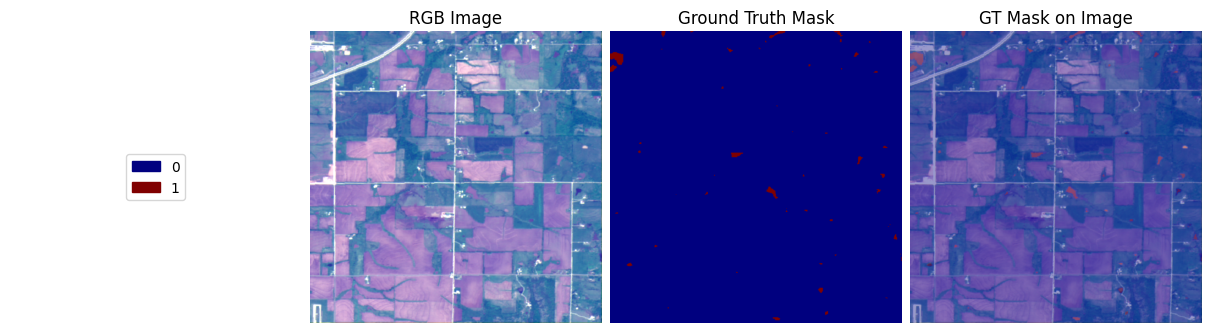

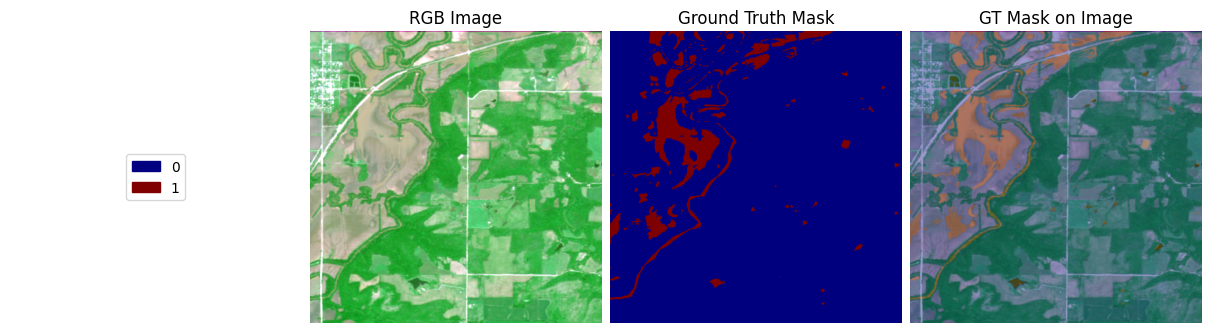

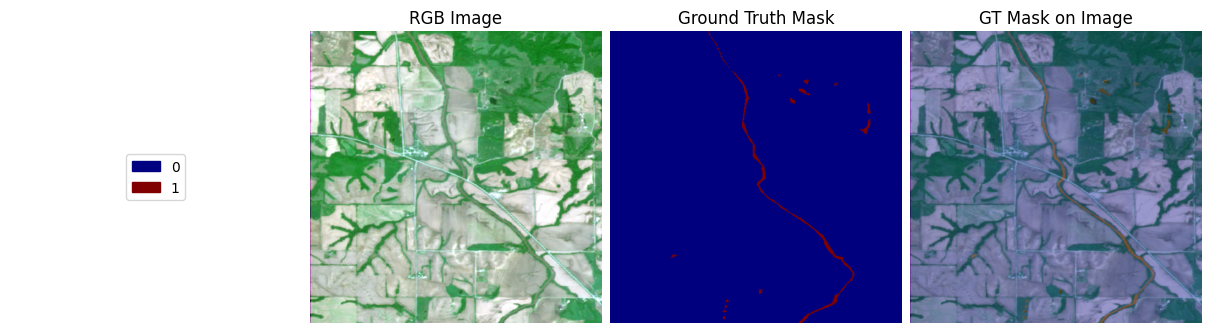

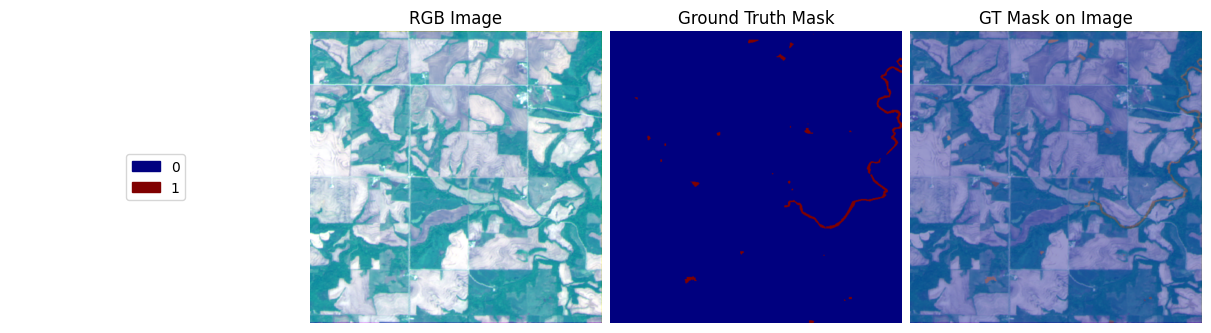

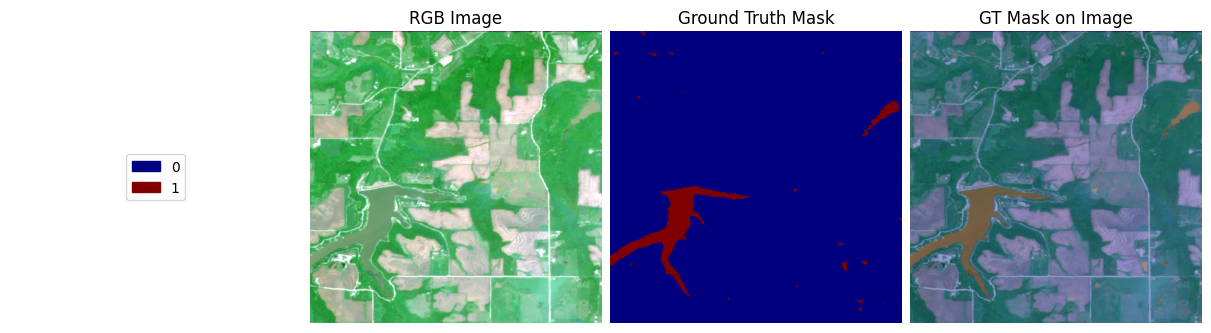

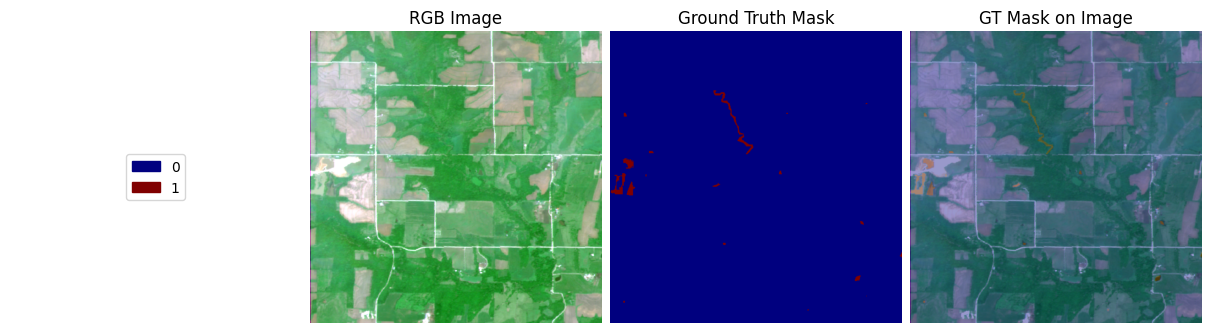

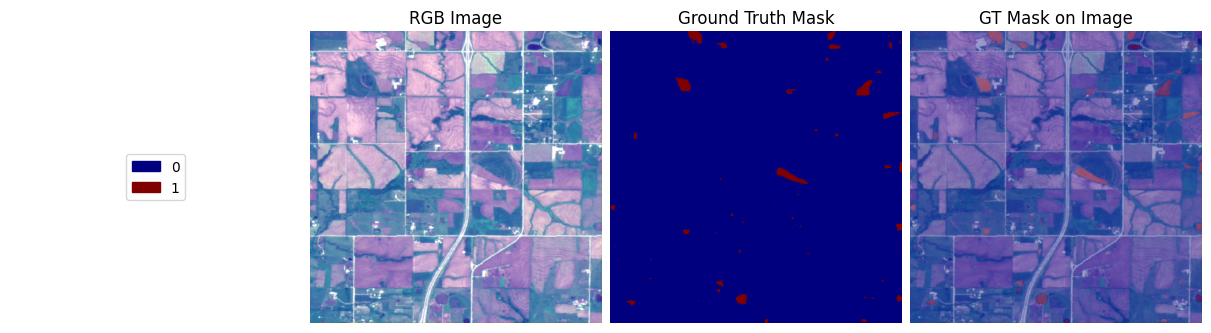

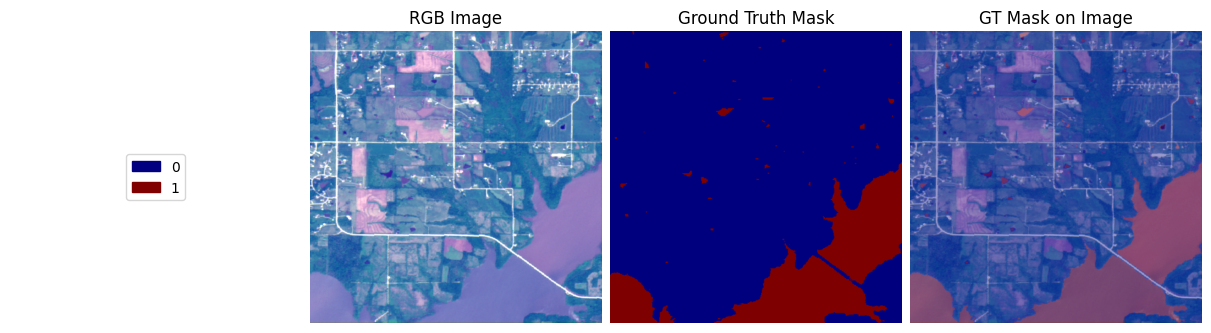

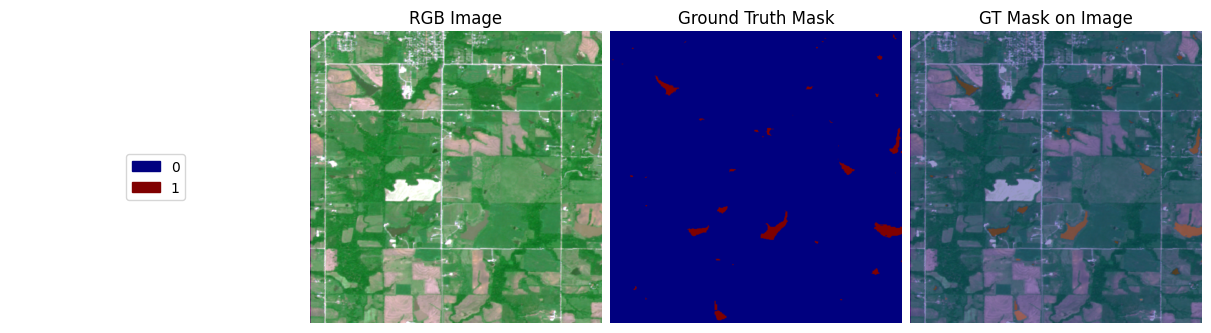

In [71]:
for i in range(80, 89):
    _ = test_dataset.plot(test_dataset[i])

In [8]:
logger = logging.getLogger(__name__)

BACKBONE_SIZES = {"tiny", "small", "base", "large"}
BACKBONE_NECK_INDICES = {
    "tiny": [1, 3, 4, 5],
    "small": [1, 3, 4, 5],
    "base": [2, 5, 8, 11],
    "large": [5, 11, 17, 23],
}

SIM_BACKBONE_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2, "PAN": 3, 
        "B08": 4, "B05": 5, "B06": 6, "B07": 7
    }
}

backbone_size = "base"
backbone_name = f"terramind_v1_{backbone_size}"
neck_indices = BACKBONE_NECK_INDICES[backbone_size]

model_args = {
    "backbone": backbone_name,
    "backbone_pretrained": True,
    "backbone_modalities": ["S2L1C"],
    "backbone_bands": SIM_BACKBONE_BANDS,
    # Necks
    "necks": [
        {"name": "SelectIndices", "indices": neck_indices},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"},
    ],
    # Decoder
    "decoder": "UNetDecoder",
    "decoder_channels": [256, 128, 64, 32],
    # Head
    "head_dropout": 0.1,
    "num_classes": 2,
}

task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
    lr=2e-5,
    ignore_index=-1,
    plot_on_val=False,
    loss="ce",
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    class_names=["background", "flood"],
    freeze_backbone=True,
)

2026-05-27 14:19:03,013 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"


In [10]:
experiment_name = f"terramind_v1_{backbone_size}_simulated_set_flipped"
output_dir="/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods_simulated"
logger = WandbLogger(project="terra-sat-drift", name=experiment_name, save_dir=root_dir)

checkpoint_callback = ModelCheckpoint(
    dirpath=output_dir + f"/{experiment_name}/checkpoints",
    filename="best-val_mIoU",
    monitor="val/mIoU",
    mode="max",
    save_top_k=3,
    verbose=True,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    patience=10,
    mode="max",
    verbose=True,
)

trainer = Trainer(
    max_epochs=50,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
datamodule.setup(stage="fit")
trainer.fit(model=task, datamodule=datamodule)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /shared/home/elucas/.netrc.


wandb: Currently logged in as: elouannlucas56 (elouannlucas56-universit-bretagne-sud) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods_simulated/terramind_v1_tiny_simulated/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  8.1 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 5.7 M                                                                                        
Total params: 8.1 M                                                                                                
Total estimated model params size (MB): 32                                                                         
Modules in train mode: 288                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

SystemExit: 1

/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7d6d6517f410>> (for post_run_cell), with arguments args (<ExecutionResult object at 7d6d651fa6d0, execution_count=6 error_before_exec=None error_in_exec=1 info=<ExecutionInfo object at 7d6d6522d6d0, raw_cell="logging.basicConfig(
    level=logging.INFO,
    f.." transformed_cell="logging.basicConfig(
    level=logging.INFO,
    f.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Bneohpc-phi-gpu-15/shared/home/elucas/terra-sat-drift/train_validate_floods_simulated.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

: 

In [16]:
task = SemanticSegmentationTask.load_from_checkpoint(checkpoint_path="/shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_sen1floods_simulated/terramind_v1_base_simulated_set_flipped/checkpoints/best-val_mIoU.ckpt")

datamodule.setup(stage="test")
trainer.test(model=task, dataloaders=datamodule)

2026-05-27 14:25:16,573 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
2026-05-27 14:25:18,615 - INFO - Checking stackability for test split.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric           ┃          DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/Accuracy          │       0.9338522553443909       │
│       test/Boundary_mIoU       │      0.14085309207439423       │
│ test/Class_Accuracy_background │       0.979128897190094        │
│   test/Class_Accuracy_flood    │       0.8885756134986877       │
│         test/F1_Score          │       0.9269688129425049       │
│      test/IoU_background       │       0.9640721678733826       │
│         test/IoU_flood         │       0.7734112739562988       │
│      test/Pixel_Accuracy       │       0.9679969549179077       │
│           test/loss            │      0.27657055854797363       │
│           test/mIoU            │       0.8687417507171631       │
│        test/mIoU_Micro         │       0.9379786252975464       │
└────────────────────────────────┴────────────────────────────────┘

[{'test/loss': 0.27657055854797363,
  'test/Accuracy': 0.9338522553443909,
  'test/Boundary_mIoU': 0.14085309207439423,
  'test/Class_Accuracy_background': 0.979128897190094,
  'test/Class_Accuracy_flood': 0.8885756134986877,
  'test/F1_Score': 0.9269688129425049,
  'test/IoU_background': 0.9640721678733826,
  'test/IoU_flood': 0.7734112739562988,
  'test/Pixel_Accuracy': 0.9679969549179077,
  'test/mIoU': 0.8687417507171631,
  'test/mIoU_Micro': 0.9379786252975464}]

## 3. Prepare Sample Data and Create RGB Composites

In [17]:
task.eval()

datamodule.setup("test")

test_loader = datamodule.test_dataloader()
test_dataset = datamodule.test_dataset
print(f"Available samples in the test dataset: {len(test_dataset)}")

2026-05-27 14:27:44,583 - INFO - Checking stackability for test split.


Available samples in the test dataset: 89


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7c20ec263290>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7c21f1789850, raw_cell="with torch.no_grad():
    batch = next(iter(test_l.." transformed_cell="with torch.no_grad():
    batch = next(iter(test_l.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Bneohpc-phi-gpu-15/shared/home/elucas/scratch/terra-sat-drift/train_validate_floods_simulated.ipynb#X16sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

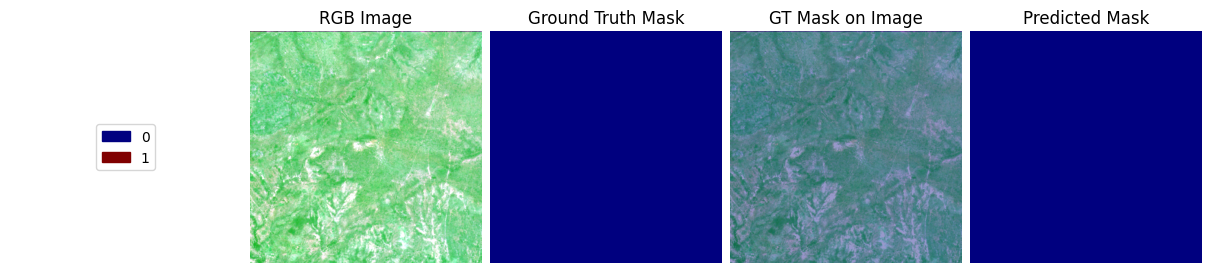

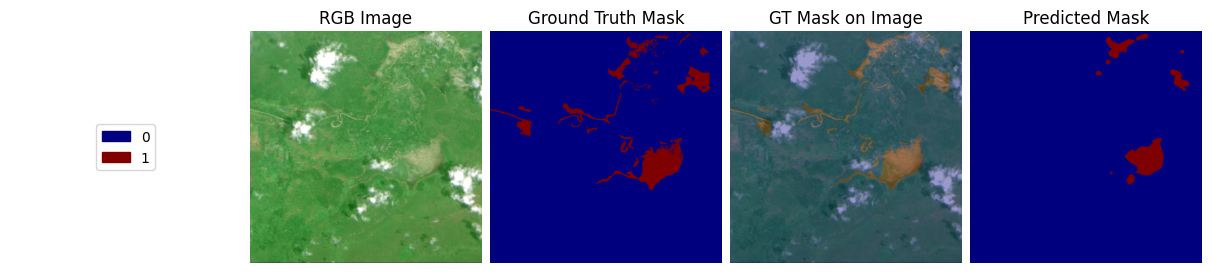

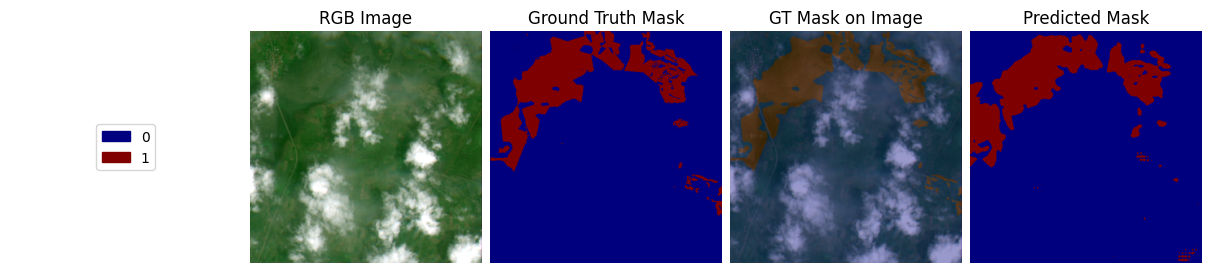

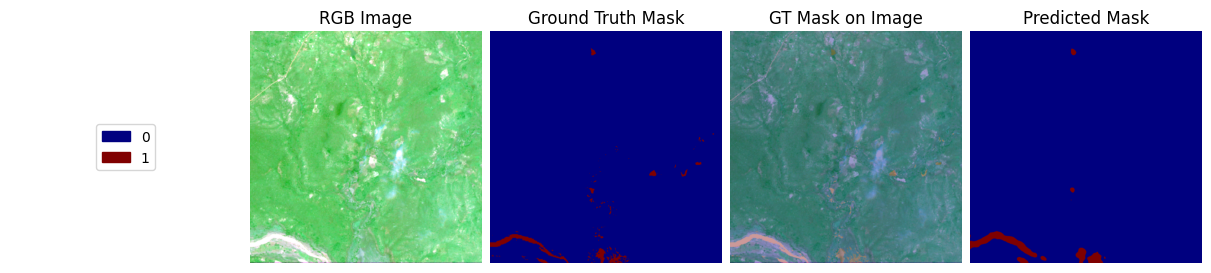

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7c20ec263290>> (for post_run_cell), with arguments args (<ExecutionResult object at 7c21f260c510, execution_count=20 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7c21f1789850, raw_cell="with torch.no_grad():
    batch = next(iter(test_l.." transformed_cell="with torch.no_grad():
    batch = next(iter(test_l.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Bneohpc-phi-gpu-15/shared/home/elucas/scratch/terra-sat-drift/train_validate_floods_simulated.ipynb#X16sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [20]:
with torch.no_grad():
    batch = next(iter(test_loader))
    # Apply the same normalization used during training
    batch = datamodule.aug(batch)
    images = batch["image"].to(task.device)
    masks = batch["mask"].cpu().numpy()

    outputs = task(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

# Visualize a few predictions
num_examples = min(6, len(preds))
for i in range(2, num_examples):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i].squeeze().cpu(),
        "prediction": preds[i],
    }
    test_dataset.plot(sample)